#**SET UP AWAL DAN INSTALASI LIBRARY**

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Instalasi Library yang Dibutuhkan
!pip install scikit-learn
!pip install pyyaml
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.4 MB/s eta 0:00:00


#**DATA TRAIN RDD2022**

In [ ]:
!mkdir -p /content/RDD2022
!unzip -q "/content/drive/MyDrive/RDD2022.zip" -d "/content/RDD2022"

print(" Selesai!")

 Selesai!


In [ ]:
import os
import json
from collections import Counter

# --- 1. Konfigurasi Jalur ---
SOURCE_ANN_DIR = "/content/RDD2022/RDD2022/train/ann"

# Inisialisasi penghitung
found_titles = Counter()
total_annotations = 0

print("---  ─ Mencari Distribusi Kelas MENTAH di JSON (DATA GLOBAL) ---")

# 2. Membuat daftar SEMUA file JSON
all_files = [f for f in os.listdir(SOURCE_ANN_DIR) if f.endswith(".json")]

if not all_files:
    print(f"Error: Tidak ditemukan file anotasi JSON di {SOURCE_ANN_DIR}")
    exit() # Changed 'return' to 'exit()'

print(f" Ditemukan {len(all_files)} file anotasi GLOBAL untuk dianalisis.")

# 3. Iterasi dan Hitung Nama Kelas
for json_filename in all_files:
    json_path = os.path.join(SOURCE_ANN_DIR, json_filename)

    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
    except Exception as e:
        # Menghindari kegagalan jika ada file JSON yang rusak
        continue

    for obj in data.get('objects', []):
        class_title = obj.get('classTitle') # Mengambil nama kelas mentah dari JSON
        if class_title:
            found_titles[class_title] += 1
            total_annotations += 1

print("\n--- Distribusi Kelas Asli GLOBAL ---")
print(f"Total Anotasi Keseluruhan: {total_annotations}")
print("===================================================")

for title, count in found_titles.most_common():
    print(f"- {title}: {count} ({count/total_annotations*100:.2f}%)")

print("\n--- Selesai: Ini adalah distribusi 7 kelas penuh ---")

---  ─ Mencari Distribusi Kelas MENTAH di JSON (DATA GLOBAL) ---
 Ditemukan 38385 file anotasi GLOBAL untuk dianalisis.

--- Distribusi Kelas Asli GLOBAL ---
Total Anotasi Keseluruhan: 61082
- longitudinal crack: 26196 (42.89%)
- transverse crack: 11875 (19.44%)
- alligator crack: 10617 (17.38%)
- pothole: 6544 (10.71%)
- other corruption: 5850 (9.58%)

--- Selesai: Ini adalah distribusi 7 kelas penuh ---


In [ ]:
import numpy as np

# Persentase kelas untuk seluruh data GLOBAL (diinput manual)
# [Long.%, Trans.%, Alli.%, Pothole%, Other Cor.%]
global_percentages = np.array([42.89, 19.44, 17.38, 10.71, 9.58])

# Hitung Standar Deviasi (Standard Deviation, sigma)
global_std = np.std(global_percentages)

print(f"Persentase Kelas Global: {global_percentages}")
print(f"Standar Deviasi GLOBAL: {global_std:.2f}")

Persentase Kelas Global: [42.89 19.44 17.38 10.71  9.58]
Standar Deviasi GLOBAL: 12.05


#**DATA TES RDD2022**

In [ ]:
import os
import json
from collections import Counter

# --- 1. Konfigurasi Jalur (DIUBAH ke FOLDER TEST) ---
BASE_DRIVE_PATH = "/content/drive/MyDrive"
# Mengubah 'train' menjadi 'test'
SOURCE_ANN_TEST_DIR = os.path.join(BASE_DRIVE_PATH, "RDD2022", "test", "ann")

# Inisialisasi penghitung
found_titles_test = Counter()
total_annotations_test = 0

print("--- Mencari Distribusi Kelas di TEST SET ---")

# 2. Membuat daftar SEMUA file JSON di Test
all_test_files = [f for f in os.listdir(SOURCE_ANN_TEST_DIR) if f.endswith(".json")]

if not all_test_files:
    print(f"Error: Tidak ditemukan file anotasi JSON di {SOURCE_ANN_TEST_DIR}")
    exit() # Changed 'return' to 'exit()'

print(f" Ditemukan {len(all_test_files)} file anotasi TEST untuk dianalisis.")

# 3. Iterasi dan Hitung Nama Kelas
for json_filename in all_test_files:
    json_path = os.path.join(SOURCE_ANN_TEST_DIR, json_filename)

    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
    except Exception as e:
        # Melewati file yang rusak
        continue

    for obj in data.get('objects', []):
        class_title = obj.get('classTitle')
        if class_title:
            found_titles_test[class_title] += 1
            total_annotations_test += 1

print("\n--- Distribusi Kelas Asli TEST SET ---")
print(f"Total Anotasi Keseluruhan di Test Set: {total_annotations_test}")
print("===================================================")

for title, count in found_titles_test.most_common():
    print(f"- {title}: {count} ({count/total_annotations_test*100:.2f}%)")

print("\n--- Selesai: Bandingkan hasil ini dengan 5 kelas yang sudah ada ---")

--- Mencari Distribusi Kelas di TEST SET ---
✅ Ditemukan 9035 file anotasi TEST untuk dianalisis.

--- Distribusi Kelas Asli TEST SET ---
Total Anotasi Keseluruhan di Test Set: 0

--- Selesai: Bandingkan hasil ini dengan 5 kelas yang sudah ada ---


#**DISTRIBUSI DATA TIAP NEGARA**

In [ ]:
LOCAL_DEST_DIR = "/content/local_ann"
ZIP_FILE_PATH = "/content/ann.zip"

# Buat folder tujuan (jika belum ada)
!mkdir -p {LOCAL_DEST_DIR}

# Ekstrak file ZIP ke folder tujuan
# -q untuk mode tenang (quiet)
!unzip -q {ZIP_FILE_PATH} -d {LOCAL_DEST_DIR}

unzip:  cannot find or open /content/ann.zip, /content/ann.zip.zip or /content/ann.zip.ZIP.


In [ ]:
import os
import json
import re
from collections import Counter, defaultdict
from tqdm.notebook import tqdm
import numpy as np

# --- KONFIGURASI JALUR ---
SOURCE_ANN_DIR = "/content/local_ann/ann"

# Menggunakan 5 kelas target
TARGET_CLASSES = [
    "longitudinal crack", "transverse crack", "alligator crack",
    "pothole", "other corruption"
]

# --- MAPPING KHUSUS CHINA ---
COUNTRY_RENAMING = {
    'China_MotorBike': 'China_Gabungan',
    'China_Drone': 'China_Gabungan'
}

# --- FUNGSI UTAMA ANALISIS ---
def analyze_country_distribution_combined_with_std(): # Ganti nama fungsi
    print("--- Analisis Distribusi Kelas Per Negara (6 Subset Gabungan) ---")

    country_data = defaultdict(lambda: {
        'images': 0,
        'annotations': 0,
        'class_counts': Counter()
    })

    try:
        all_files = [f for f in os.listdir(SOURCE_ANN_DIR) if f.endswith(".json")]
    except OSError as e:
        print(f" Error: Gagal mengakses folder lokal. Pastikan jalur '{SOURCE_ANN_DIR}' benar. ({e})")
        return

    print(f" Memulai analisis pada {len(all_files)} file anotasi...")

    REGEX_PATTERN = r'([A-Za-z_]+?)_\d+\.jpg\.json'

    for json_filename in tqdm(all_files, desc="Memproses Semua File"):
        match = re.match(REGEX_PATTERN, json_filename)

        if not match: continue

        country_name_raw = match.group(1)

        country_key = COUNTRY_RENAMING.get(country_name_raw, country_name_raw)

        json_path = os.path.join(SOURCE_ANN_DIR, json_filename)

        try:
            with open(json_path, 'r') as f:
                data = json.load(f)
        except Exception:
            continue

        country_data[country_key]['images'] += 1

        for obj in data.get('objects', []):
            class_title = obj.get('classTitle')
            if class_title in TARGET_CLASSES:
                country_data[country_key]['class_counts'][class_title] += 1
                country_data[country_key]['annotations'] += 1

    # 3. Menampilkan Hasil Perbandingan
    print("\n--- Hasil Distribusi Perbandingan Negara ---")

    # Menambahkan 1 kolom untuk Standar Deviasi (Std Dev)
    header = "{:<18} {:<10} {:<10} {:<11} {:<11} {:<11} {:<11} {:<11} {:<15} {:<10}".format(
        "Negara/Subset", "Images", "Total Ann", "Long. %", "Trans. %", "Alli. %", "Pothole %", "Other Cor. %", "Imbalance Score", "Std Dev"
    )
    print(header)
    print("-" * 155) # Panjang garis disesuaikan

    for country, data in sorted(country_data.items()):
        total_ann = data['annotations']
        if total_ann == 0: continue

        # Hitung Persentase
        pct_long = data['class_counts'].get('longitudinal crack', 0) / total_ann * 100
        pct_trans = data['class_counts'].get('transverse crack', 0) / total_ann * 100
        pct_alli = data['class_counts'].get('alligator crack', 0) / total_ann * 100
        pct_pothole = data['class_counts'].get('pothole', 0) / total_ann * 100
        pct_other = data['class_counts'].get('other corruption', 0) / total_ann * 100

        # Hitung Imbalance Score
        imbalance_score = pct_pothole + pct_other

        # Hitung Standar Deviasi dari 5 persentase kelas
        all_percentages = np.array([pct_long, pct_trans, pct_alli, pct_pothole, pct_other])
        std_dev = np.std(all_percentages)

        # Format baris output untuk menyertakan Std Dev
        row = "{:<18} {:<10} {:<10} {:<11.2f} {:<11.2f} {:<11.2f} {:<11.2f} {:<11.2f} {:<15.2f} {:<10.2f}".format(
            country.replace('_', ' '),
            data['images'],
            total_ann,
            pct_long,
            pct_trans,
            pct_alli,
            pct_pothole,
            pct_other,
            imbalance_score,
            std_dev # Nilai Standar Deviasi
        )
        print(row)

    print("=" * 155)
    print("TIPS: Pilih negara dengan 'Imbalance Score' tertinggi (untuk keragaman Pothole/Other Cor) atau 'Std Dev' terendah (untuk keseimbangan 5 kelas).")

# --- EKSEKUSI ---
analyze_country_distribution_combined_with_std()

--- Analisis Distribusi Kelas Per Negara (6 Subset Gabungan) ---
 Memulai analisis pada 38385 file anotasi...


Memproses Semua File:   0%|          | 0/38385 [00:00<?, ?it/s]


--- Hasil Distribusi Perbandingan Negara ---
Negara/Subset      Images     Total Ann  Long. %     Trans. %    Alli. %     Pothole %   Other Cor. % Imbalance Score Std Dev   
-----------------------------------------------------------------------------------------------------------------------------------------------------------
China Gabungan     4378       7718       53.17       30.56       12.10       4.16        0.00        4.16            19.62     
Czech              2829       1745       56.62       22.87       9.23        11.29       0.00        11.29           19.70     
India              7706       8175       21.22       1.38        24.72       38.98       13.69       52.67           12.42     
Japan              10506      21201      19.10       18.77       29.24       10.58       22.31       32.89           6.03      
Norway             8161       11229      76.32       15.41       4.17        4.11        0.00        4.11            28.62     
United States      4805      

In [ ]:
import os
import json
import re
from collections import Counter, defaultdict
from tqdm.notebook import tqdm
import numpy as np

# --- KONFIGURASI JALUR LOKAL ---
# Mengarah ke folder hasil ekstrak di Colab lokal
SOURCE_ANN_DIR = "/content/RDD2022/RDD2022/train/ann"

# Menggunakan 5 kelas target
TARGET_CLASSES = [
    "longitudinal crack", "transverse crack", "alligator crack",
    "pothole", "other corruption"
]

# --- MAPPING KHUSUS CHINA ---
COUNTRY_RENAMING = {
    'China_MotorBike': 'China_Gabungan',
    'China_Drone': 'China_Gabungan'
}

# --- FUNGSI UTAMA ANALISIS ---
def analyze_country_distribution_combined_with_std():
    print("--- Analisis Distribusi Kelas Per Negara (Jumlah & Persentase) ---")

    country_data = defaultdict(lambda: {
        'images': 0,
        'annotations': 0,
        'class_counts': Counter()
    })

    try:
        all_files = [f for f in os.listdir(SOURCE_ANN_DIR) if f.endswith(".json")]
    except OSError as e:
        print(f" Error: Gagal mengakses folder lokal. Pastikan jalur '{SOURCE_ANN_DIR}' benar. ({e})")
        return

    print(f" Memulai analisis pada {len(all_files)} file anotasi...")

    REGEX_PATTERN = r'([A-Za-z_]+?)_\d+\.jpg\.json'

    for json_filename in tqdm(all_files, desc="Memproses Semua File"):
        match = re.match(REGEX_PATTERN, json_filename)

        if not match: continue

        country_name_raw = match.group(1)
        country_key = COUNTRY_RENAMING.get(country_name_raw, country_name_raw)

        json_path = os.path.join(SOURCE_ANN_DIR, json_filename)

        try:
            with open(json_path, 'r') as f:
                data = json.load(f)
        except Exception:
            continue

        country_data[country_key]['images'] += 1

        for obj in data.get('objects', []):
            class_title = obj.get('classTitle')
            if class_title in TARGET_CLASSES:
                country_data[country_key]['class_counts'][class_title] += 1
                country_data[country_key]['annotations'] += 1

    # 3. Menampilkan Hasil Perbandingan
    print("\n--- Hasil Distribusi Perbandingan Negara ---")

    # Format Header (Imbalance Score DIHAPUS)
    # Lebar total dikurangi karena 1 kolom hilang
    header = "{:<18} {:<8} {:<10} {:<20} {:<20} {:<20} {:<20} {:<20} {:<10}".format(
        "Negara/Subset", "Img", "Tot Ann",
        "Long. (N|%)", "Trans. (N|%)", "Alli. (N|%)", "Pothole (N|%)", "Other (N|%)",
        "Std Dev"
    )

    print("-" * 170) # Garis pemisah disesuaikan
    print(header)
    print("-" * 170)

    for country, data in sorted(country_data.items()):
        total_ann = data['annotations']
        if total_ann == 0: continue

        # --- A. Ambil Jumlah Integer (Count) ---
        cnt_long = data['class_counts'].get('longitudinal crack', 0)
        cnt_trans = data['class_counts'].get('transverse crack', 0)
        cnt_alli = data['class_counts'].get('alligator crack', 0)
        cnt_pothole = data['class_counts'].get('pothole', 0)
        cnt_other = data['class_counts'].get('other corruption', 0)

        # --- B. Hitung Persentase (Float) ---
        pct_long = cnt_long / total_ann * 100
        pct_trans = cnt_trans / total_ann * 100
        pct_alli = cnt_alli / total_ann * 100
        pct_pothole = cnt_pothole / total_ann * 100
        pct_other = cnt_other / total_ann * 100

        # --- C. Format String Gabungan "Jumlah (Persen%)" ---
        str_long = f"{cnt_long} ({pct_long:.1f}%)"
        str_trans = f"{cnt_trans} ({pct_trans:.1f}%)"
        str_alli = f"{cnt_alli} ({pct_alli:.1f}%)"
        str_pothole = f"{cnt_pothole} ({pct_pothole:.1f}%)"
        str_other = f"{cnt_other} ({pct_other:.1f}%)"

        # Hitung Metrik Statistik (Hanya Std Dev)
        all_percentages = np.array([pct_long, pct_trans, pct_alli, pct_pothole, pct_other])
        std_dev = np.std(all_percentages)

        # Print Baris (Imbalance Score DIHAPUS)
        row = "{:<18} {:<8} {:<10} {:<20} {:<20} {:<20} {:<20} {:<20} {:<10.2f}".format(
            country.replace('_', ' '),
            data['images'],
            total_ann,
            str_long,
            str_trans,
            str_alli,
            str_pothole,
            str_other,
            std_dev
        )
        print(row)

    print("=" * 170)
    print("Keterangan: Format kolom kelas adalah 'Jumlah Anotasi (Persentase)'.")

# --- EKSEKUSI ---
analyze_country_distribution_combined_with_std()

--- Analisis Distribusi Kelas Per Negara (Jumlah & Persentase) ---
 Memulai analisis pada 38385 file anotasi...


Memproses Semua File:   0%|          | 0/38385 [00:00<?, ?it/s]


--- Hasil Distribusi Perbandingan Negara ---
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Negara/Subset      Img      Tot Ann    Long. (N|%)          Trans. (N|%)         Alli. (N|%)          Pothole (N|%)        Other (N|%)          Std Dev   
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
China Gabungan     4378     7718       4104 (53.2%)         2359 (30.6%)         934 (12.1%)          321 (4.2%)           0 (0.0%)             19.62     
Czech              2829     1745       988 (56.6%)          399 (22.9%)          161 (9.2%)           197 (11.3%)          0 (0.0%)             19.70     
India              7706     8175       1735 (21.2%)         113 (1.4%)           2021 (24.7%)         3187 (39.0%)         1119 (13.7%)         12.

#**KONVERSI JSON DAN SPLIT US DATA**

In [ ]:
IMAGE_ZIP_FILE = "/content/drive/MyDrive/RDD2022/train/img.zip"
LOCAL_IMG_DIR = "/content/local_img"

# Buat folder tujuan (jika belum ada)
!mkdir -p {LOCAL_IMG_DIR}

# Ekstrak file ZIP ke folder tujuan
# -q untuk mode tenang (quiet)
!unzip -q {IMAGE_ZIP_FILE} -d {LOCAL_IMG_DIR}

In [ ]:
import os
import json
import shutil
import random
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

# --- 1. KONFIGURASI JALUR ---
BASE_DRIVE_PATH = "/content/drive/MyDrive"
SOURCE_IMG_DIR = "/content/local_img/img"
SOURCE_ANN_DIR = "/content/local_ann/ann"
OUTPUT_DIR = os.path.join(BASE_DRIVE_PATH, "RDD2022_JP_YOLO")

# --- 2. PEMETAAN KELAS (5 Kelas Penuh untuk Japan) ---
CLASS_MAPPING = {
    "longitudinal crack": 0,    # ID 0
    "transverse crack": 1,      # ID 1
    "alligator crack": 2,       # ID 2
    "pothole": 3,               # ID 3
    "other corruption": 4,      # ID 4
}

# --- 3. FUNGSI UTILITAS ---
def normalize_yolo_coords(points, img_w, img_h):
    xmin, ymin = points[0]
    xmax, ymax = points[1]

    center_x = (xmin + xmax) / 2.0
    center_y = (ymin + ymax) / 2.0
    w = xmax - xmin
    h = ymax - ymin

    center_x /= img_w
    center_y /= img_h
    w /= img_w
    h /= img_h

    return f"{center_x:.6f} {center_y:.6f} {w:.6f} {h:.6f}"

# --- 4. PEMROSESAN DATA UTAMA (Japan) ---
def process_rdd_japan_data():
    print("--- Memulai Pra-pemrosesan RDD2022 KHUSUS JAPAN (5 KELAS) ---")

    all_files = [f for f in os.listdir(SOURCE_ANN_DIR) if f.startswith("Japan_") and f.endswith(".json")]

    if not all_files:
        print(f"ERROR: Tidak ditemukan file anotasi 'Japan_*.json' di {SOURCE_ANN_DIR}")
        return

    print(f"Ditemukan {len(all_files)} file anotasi Japan.")
    dataset = []
    annotations_count = 0

    for json_filename in tqdm(all_files, desc="Mengonversi Anotasi Japan"):

        # Logika untuk mendapatkan base_name tanpa .jpg atau .json
        base_name = json_filename.replace(".json", "")
        if base_name.endswith(".jpg"):
            base_name = base_name[:-4] # Hapus ".jpg"

        json_path = os.path.join(SOURCE_ANN_DIR, json_filename)
        yolo_lines = []

        try:
            with open(json_path, 'r') as f:
                data = json.load(f)
        except Exception:
            continue

        if 'size' not in data: continue
        img_w = data['size']['width']
        img_h = data['size']['height']

        for obj in data.get('objects', []):
            class_title = obj.get('classTitle')
            points = obj.get('points', {}).get('exterior')

            if class_title in CLASS_MAPPING and points and len(points) == 2:
                new_class_id = CLASS_MAPPING[class_title]
                yolo_coords = normalize_yolo_coords(points, img_w, img_h)
                yolo_lines.append(f"{new_class_id} {yolo_coords}")
                annotations_count += 1

        if yolo_lines:
            dataset.append((base_name, yolo_lines))

    print(f"\nTotal {len(dataset)} gambar yang memiliki anotasi berhasil dikonversi.")
    print(f"Total {annotations_count} anotasi berhasil dibuat.")

    # 2. Split Data (80% Train, 20% Val)
    print("--- Membagi Data (80% Train / 20% Val) ---")
    train_data, val_data = train_test_split(dataset, test_size=0.2, random_state=42)
    print(f"Train Set: {len(train_data)} gambar. Val Set: {len(val_data)} gambar.")

    # 3. Pembuatan Struktur Folder Output & Menyalin File
    print("--- Menyalin Gambar & Menulis Label YOLO ---")

    for folder in ['train/images', 'train/labels', 'val/images', 'val/labels']:
        os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

    total_copies = len(train_data) + len(val_data)
    copy_progress = tqdm(total=total_copies, desc="Menyimpan ke Drive")

    for set_name, data_list in [('train', train_data), ('val', val_data)]:
        target_img_dir = os.path.join(OUTPUT_DIR, set_name, 'images')
        target_label_dir = os.path.join(OUTPUT_DIR, set_name, 'labels')

        for base_name, yolo_lines in data_list:

            # --- Penamaan File Benar ---
            source_img_name = f"{base_name}.jpg" # Japan_0001.jpg
            source_img_path = os.path.join(SOURCE_IMG_DIR, source_img_name)
            target_img_path = os.path.join(target_img_dir, source_img_name)
            target_label_path = os.path.join(target_label_dir, f"{base_name}.txt") # Japan_0001.txt

            # Penyalinan Gambar (Hanya jika file ada di sumber lokal)
            if os.path.exists(source_img_path):
                # Menyalin dari lokal ke Drive (tahap output)
                shutil.copy2(source_img_path, target_img_path)

            # Penulisan Label
            with open(target_label_path, 'w') as f:
                f.write('\n'.join(yolo_lines))

            copy_progress.update(1) # Update progress

    copy_progress.close()

    print("--- Semua Selesai ---")
    print(f"Data siap di: {OUTPUT_DIR}")

# --- EKSEKUSI FUNGSI ---
process_rdd_japan_data()

--- Memulai Pra-pemrosesan RDD2022 KHUSUS JAPAN (5 KELAS) ---
Ditemukan 10506 file anotasi Japan.


Mengonversi Anotasi Japan:   0%|          | 0/10506 [00:00<?, ?it/s]


Total 9311 gambar yang memiliki anotasi berhasil dikonversi.
Total 21201 anotasi berhasil dibuat.
--- Membagi Data (80% Train / 20% Val) ---
Train Set: 7448 gambar. Val Set: 1863 gambar.
--- Menyalin Gambar & Menulis Label YOLO ---


Menyimpan ke Drive:   0%|          | 0/9311 [00:00<?, ?it/s]

--- Semua Selesai ---
Data siap di: /content/drive/MyDrive/RDD2022_JP_YOLO


#**VERIFIKASI DISTRIBUSI KELAS AHKIR**

--- Penghitungan Jumlah dan Distribusi Kelas JAPAN (5 Kategori) ---

## Data Pelatihan (Train)
Jumlah gambar/file label: **7448**
Distribusi Kelas (ID Kelas: Jumlah Anotasi):
[(2, 4966), (4, 3786), (0, 3205), (1, 3173), (3, 1781)]

## Data Validasi (Validation/Val)
Jumlah gambar/file label: **1863**
Distribusi Kelas (ID Kelas: Jumlah Anotasi):
[(2, 1233), (4, 945), (0, 844), (1, 806), (3, 462)]

## Ringkasan Total Global (Train + Val)
Total Gambar Unik yang Diolah: **9311**
Total Anotasi (Bounding Box): **21201**

## Visualisasi


/tmp/ipython-input-1362064213.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_cmap = plt.cm.get_cmap('Spectral', 5)


Grafik distribusi telah disimpan sebagai distribution_japan_5class_fixed.png


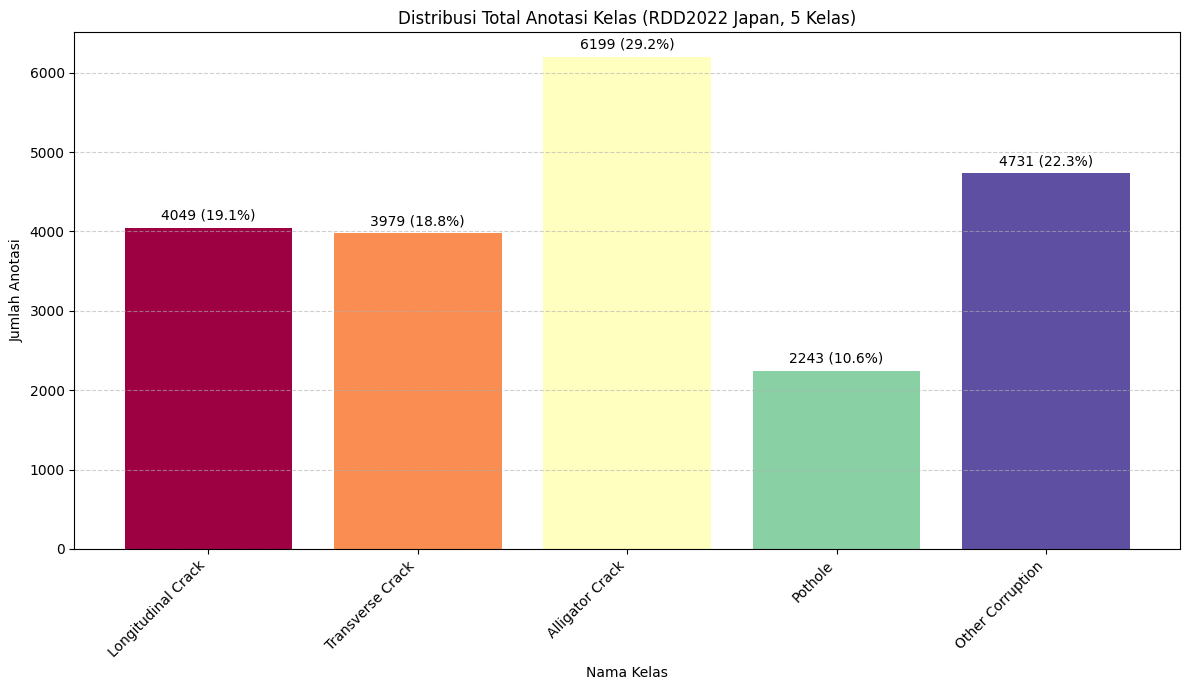

In [ ]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# --- Konfigurasi ---
path_dataset = "/content/drive/MyDrive/RDD2022_JP_YOLO"
train_labels_dir = os.path.join(path_dataset, "train", "labels")
val_labels_dir = os.path.join(path_dataset, "val", "labels")

# Definisikan 5 Nama Kelas
CLASS_MAPPING_5_CLASSES = {
    0: "Longitudinal Crack", 1: "Transverse Crack", 2: "Alligator Crack",
    3: "Pothole", 4: "Other Corruption"
}
CLASS_NAMES = [CLASS_MAPPING_5_CLASSES[i] for i in sorted(CLASS_MAPPING_5_CLASSES.keys())]

# Inisialisasi penghitung
class_counts = Counter()

## Fungsi untuk Membaca dan Menghitung Kelas dari File Label (Sudah Diperbaiki)
def count_classes(labels_dir):
    local_counts = Counter()
    total_files = 0
    if not os.path.exists(labels_dir): return local_counts, 0

    for filename in os.listdir(labels_dir):
        if filename.endswith(".txt"):
            file_path = os.path.join(labels_dir, filename)
            total_files += 1

            try:
                with open(file_path, 'r') as f:
                    content = f.read().split()
                    if not content: continue
                    for i in range(0, len(content), 5):
                        class_id = int(content[i])
                        local_counts[class_id] += 1
            except Exception as e:
                print(f"Error membaca file {filename}: {e}")
                pass
    return local_counts, total_files

# --- 1. Penghitungan Data ---
print("--- Penghitungan Jumlah dan Distribusi Kelas JAPAN (5 Kategori) ---")

# Hitung data Train
print("\n## Data Pelatihan (Train)")
train_counts, total_train_files = count_classes(train_labels_dir)
class_counts.update(train_counts)
print(f"Jumlah gambar/file label: **{total_train_files}**")
print("Distribusi Kelas (ID Kelas: Jumlah Anotasi):")
print(train_counts.most_common())

# Hitung data Val
print("\n## Data Validasi (Validation/Val)")
val_counts, total_val_files = count_classes(val_labels_dir)
class_counts.update(val_counts)
print(f"Jumlah gambar/file label: **{total_val_files}**")
print("Distribusi Kelas (ID Kelas: Jumlah Anotasi):")
print(val_counts.most_common())

# --- 2. Ringkasan Global ---
print("\n## Ringkasan Total Global (Train + Val)")
total_annotations = sum(class_counts.values())
print(f"Total Gambar Unik yang Diolah: **{total_train_files + total_val_files}**")
print(f"Total Anotasi (Bounding Box): **{total_annotations}**")

# --- 3. Visualisasi Distribusi Kelas ---
print("\n## Visualisasi")

# Persiapan data untuk plotting
class_ids = sorted(class_counts.keys())
counts = [class_counts[i] for i in class_ids]

# Menggunakan nama kelas yang didefinisikan (agar sesuai dengan ID 0-4)
labels = [CLASS_MAPPING_5_CLASSES.get(i, f"ID_TIDAK_DIHARAPKAN_{i}") for i in class_ids]

plt.figure(figsize=(12, 7))
colors_cmap = plt.cm.get_cmap('Spectral', 5)
plt.bar(labels, counts, color=[colors_cmap(i) for i in np.linspace(0, 1, len(labels))])

for i, count in enumerate(counts):
    # Menambahkan nilai di atas setiap bar
    plt.text(i, count + total_annotations*0.003, f"{count} ({count/total_annotations*100:.1f}%)", ha='center', va='bottom', fontsize=10)

plt.title('Distribusi Total Anotasi Kelas (RDD2022 Japan, 5 Kelas)')
plt.xlabel('Nama Kelas')
plt.ylabel('Jumlah Anotasi')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('distribution_japan_5class_fixed.png')
print("Grafik distribusi telah disimpan sebagai distribution_japan_5class_fixed.png")

#**DATA GOOGLE DRIVE KE GOOGLE COLLAB**

In [ ]:
!zip -r /content/drive/MyDrive/RDD2022_JP_YOLO.zip /content/drive/MyDrive/RDD2022_JP_YOLO

Output streaming akan dipotong hingga 5000 baris terakhir.
  adding: content/drive/MyDrive/RDD2022_JP_YOLO/train/labels/Japan_004841.txt (deflated 35%)
  adding: content/drive/MyDrive/RDD2022_JP_YOLO/train/labels/Japan_012626.txt (deflated 32%)
  adding: content/drive/MyDrive/RDD2022_JP_YOLO/train/labels/Japan_003435.txt (deflated 24%)
  adding: content/drive/MyDrive/RDD2022_JP_YOLO/train/labels/Japan_009447.txt (deflated 27%)
  adding: content/drive/MyDrive/RDD2022_JP_YOLO/train/labels/Japan_003648.txt (deflated 32%)
  adding: content/drive/MyDrive/RDD2022_JP_YOLO/train/labels/Japan_001568.txt (deflated 24%)
  adding: content/drive/MyDrive/RDD2022_JP_YOLO/train/labels/Japan_006968.txt (deflated 50%)
  adding: content/drive/MyDrive/RDD2022_JP_YOLO/train/labels/Japan_012560.txt (deflated 44%)
  adding: content/drive/MyDrive/RDD2022_JP_YOLO/train/labels/Japan_004069.txt (deflated 39%)
  adding: content/drive/MyDrive/RDD2022_JP_YOLO/train/labels/Japan_000846.txt (deflated 33%)
  adding: c

#**EKSTRAK DATA ZIP**

In [ ]:
!cp /content/drive/MyDrive/RDD2022_JP_YOLO.zip /content/
!unzip -q /content/RDD2022_JP_YOLO.zip -d /content/rdd_data/

#**VERIFIKASI DISTRUBSI DATA ZIP**

--- Penghitungan Jumlah dan Distribusi Kelas JAPAN (5 Kategori) dari Lokasi Lokal ---

## Data Pelatihan (Train)
Jumlah gambar/file label: **7448**
Distribusi Kelas (ID Kelas: Jumlah Anotasi):
[('Longitudinal Crack', 3205), ('Transverse Crack', 3173), ('Alligator Crack', 4966), ('Pothole', 1781), ('Other Corruption', 3786)]

## Data Validasi (Validation/Val)
Jumlah gambar/file label: **1863**
Distribusi Kelas (ID Kelas: Jumlah Anotasi):
[('Transverse Crack', 806), ('Alligator Crack', 1233), ('Longitudinal Crack', 844), ('Other Corruption', 945), ('Pothole', 462)]

## Ringkasan Total Global (Train + Val)
Total Gambar Unik yang Diolah: **9311**
Total Anotasi (Bounding Box): **21201**

## Visualisasi


/tmp/ipython-input-93460122.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_cmap = plt.cm.get_cmap('Spectral', 5)


Grafik distribusi telah disimpan sebagai distribution_japan_5class_fixed.png


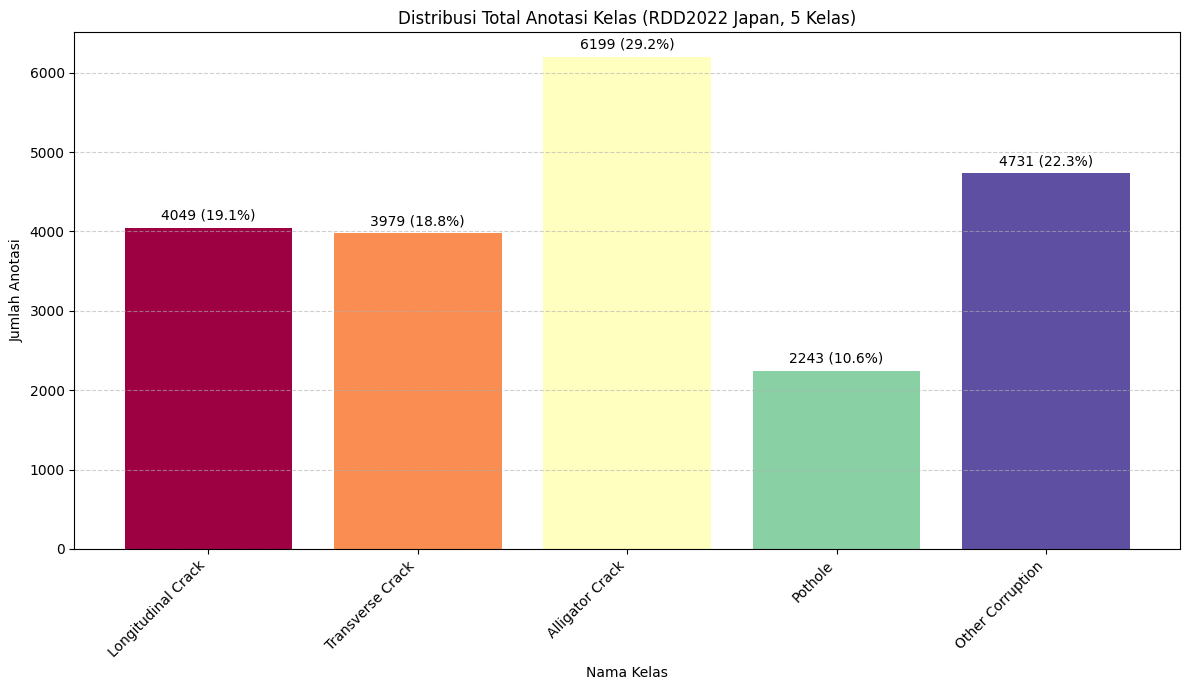

In [ ]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# --- Konfigurasi ---

path_dataset = "/content/rdd_data/content/drive/MyDrive/RDD2022_JP_YOLO"

train_labels_dir = os.path.join(path_dataset, "train", "labels")
val_labels_dir = os.path.join(path_dataset, "val", "labels")

# Definisikan 5 Nama Kelas
CLASS_MAPPING_5_CLASSES = {
    0: "Longitudinal Crack", 1: "Transverse Crack", 2: "Alligator Crack",
    3: "Pothole", 4: "Other Corruption"
}
CLASS_NAMES = [CLASS_MAPPING_5_CLASSES[i] for i in sorted(CLASS_MAPPING_5_CLASSES.keys())]

# Inisialisasi penghitung
class_counts = Counter()

## Fungsi untuk Membaca dan Menghitung Kelas dari File Label
def count_classes(labels_dir):
    local_counts = Counter()
    total_files = 0
    # Cek apakah direktori ada di lokasi lokal
    if not os.path.exists(labels_dir):
        print(f"Peringatan: Direktori label tidak ditemukan di: {labels_dir}")
        return local_counts, 0

    for filename in os.listdir(labels_dir):
        if filename.endswith(".txt"):
            file_path = os.path.join(labels_dir, filename)
            total_files += 1

            try:
                with open(file_path, 'r') as f:
                    # Membaca seluruh konten file sebagai string dan memisahkannya
                    content = f.read().split()
                    if not content: continue

                    # File YOLO memiliki format: [class_id, x_center, y_center, width, height]
                    # Kita hanya perlu mengambil setiap elemen ke-5 (indeks 0, 5, 10, dst)
                    for i in range(0, len(content), 5):
                        # Memastikan elemen adalah bilangan bulat yang valid sebelum dikonversi
                        if content[i].isdigit():
                            class_id = int(content[i])
                            local_counts[class_id] += 1
                        else:
                            # Menangani kasus baris yang rusak atau tidak sesuai format
                             print(f"Peringatan: Format ID kelas tidak valid di file {filename} pada indeks {i}")

            except Exception as e:
                # Menangkap error saat mengakses atau membaca file (misalnya izin atau encoding)
                print(f"Error membaca file {filename}: {e}")
                pass
    return local_counts, total_files

# --- 1. Penghitungan Data ---
print("--- Penghitungan Jumlah dan Distribusi Kelas JAPAN (5 Kategori) dari Lokasi Lokal ---")

# Hitung data Train
print("\n## Data Pelatihan (Train)")
train_counts, total_train_files = count_classes(train_labels_dir)
class_counts.update(train_counts)
print(f"Jumlah gambar/file label: **{total_train_files}**")
print("Distribusi Kelas (ID Kelas: Jumlah Anotasi):")
# Konversi ke nama kelas yang mudah dibaca
train_summary = [(CLASS_MAPPING_5_CLASSES.get(k, f"ID_{k}"), v) for k, v in train_counts.items()]
print(train_summary)


# Hitung data Val
print("\n## Data Validasi (Validation/Val)")
val_counts, total_val_files = count_classes(val_labels_dir)
class_counts.update(val_counts)
print(f"Jumlah gambar/file label: **{total_val_files}**")
print("Distribusi Kelas (ID Kelas: Jumlah Anotasi):")
val_summary = [(CLASS_MAPPING_5_CLASSES.get(k, f"ID_{k}"), v) for k, v in val_counts.items()]
print(val_summary)

# --- 2. Ringkasan Global ---
print("\n## Ringkasan Total Global (Train + Val)")
total_annotations = sum(class_counts.values())
print(f"Total Gambar Unik yang Diolah: **{total_train_files + total_val_files}**")
print(f"Total Anotasi (Bounding Box): **{total_annotations}**")

# --- 3. Visualisasi Distribusi Kelas ---
print("\n## Visualisasi")

# Persiapan data untuk plotting
class_ids = sorted(class_counts.keys())
counts = [class_counts[i] for i in class_ids]

# Menggunakan nama kelas yang didefinisikan (agar sesuai dengan ID 0-4)
labels = [CLASS_MAPPING_5_CLASSES.get(i, f"ID_TIDAK_DIHARAPKAN_{i}") for i in class_ids]

plt.figure(figsize=(12, 7))
colors_cmap = plt.cm.get_cmap('Spectral', 5)
plt.bar(labels, counts, color=[colors_cmap(i) for i in np.linspace(0, 1, len(labels))])

for i, count in enumerate(counts):
    # Menambahkan nilai di atas setiap bar
    plt.text(i, count + total_annotations*0.003, f"{count} ({count/total_annotations*100:.1f}%)", ha='center', va='bottom', fontsize=10)

plt.title('Distribusi Total Anotasi Kelas (RDD2022 Japan, 5 Kelas)')
plt.xlabel('Nama Kelas')
plt.ylabel('Jumlah Anotasi')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('distribution_japan_5class_fixed.png')
print("Grafik distribusi telah disimpan sebagai distribution_japan_5class_fixed.png")

#**MEMBUAT FILE YAML**

In [ ]:
import yaml
import os

# --- Konfigurasi YAML (5 Kelas) ---
data_config = {
    'path': '/content/rdd_data/content/drive/MyDrive/RDD2022_JP_YOLO',
    'train': 'train/images',
    'val': 'val/images',
    'nc': 5,
    'names': [
        'longitudinal crack',
        'transverse crack',
        'alligator crack',
        'pothole',
        'other corruption'
    ]
}

# --- Jalur Output ---
drive_folder = '/content/drive/MyDrive/RDD2022_JP_YOLO'
yaml_filename = 'rdd_data_jp_local.yaml'

# Gabungkan path
output_path = os.path.join(drive_folder, yaml_filename)

# --- Proses Penulisan File ---
try:
    os.makedirs(drive_folder, exist_ok=True)

    with open(output_path, 'w') as f:
        yaml.dump(data_config, f, sort_keys=False)

    print(f"File YAML berhasil dibuat dan disimpan di: {output_path}")
    print("STATUS: Data Japan siap 100% untuk training menggunakan 5 kelas dengan path lokal!")

except Exception as e:
    print(f"ERROR: Terjadi kesalahan saat menulis file YAML: {e}")

File YAML berhasil dibuat dan disimpan di: /content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml
STATUS: Data Japan siap 100% untuk training menggunakan 5 kelas dengan path lokal!


#**YOLOV5 NANO**

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import torch
import os

# --- KONFIGURASI JALUR & PARAMETER ---
DATA_YAML_PATH = '/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml'
OUTPUT_PROJECT = 'yolo_comparison_test'
MODEL_NAME = 'yolov5n_jp_test'

# JALUR GAMBAR UNTUK INFERENSI
INFERENCE_IMAGE_PATH = '/content/drive/MyDrive/RDD2022_JP_YOLO/val/images/Japan_000001.jpg'

# --- MEMUAT MODEL ---
model = YOLO("yolov5n.pt")

# --- PELATIHAN (TRAINING) ---
print("--- Memulai Training YOLOv5n pada RDD2022 Japan ---")
# Hasil training disimpan di variabel 'results'
results_training = model.train(
    data=DATA_YAML_PATH,
    epochs=10,
    imgsz=640,
    batch=16,
    name=MODEL_NAME,
    project=OUTPUT_PROJECT,
    device=0 if torch.cuda.is_available() else 'cpu'
)

# --- INFERENSI (PREDIKSI) ---
print("\n--- Melakukan Inferensi pada Gambar Drive ---")

if os.path.exists(INFERENCE_IMAGE_PATH):
    # Model akan menggunakan bobot terbaik yang baru saja dilatih (best.pt)
    results_inference = model(INFERENCE_IMAGE_PATH)

    # Menampilkan prediksi dalam bentuk tabel Pandas (XYXY format)
    print("\nPrediksi Objek (Top 5):")

    # Pastikan hasil inferensi berhasil sebelum mencoba mengakses properti
    if results_inference and len(results_inference) > 0:
        # Mengakses dataframe pandas dari hasil inferensi
        print(results_inference[0].to_df().head())
    else:
        print("Model berhasil dijalankan, tetapi tidak mendeteksi objek apa pun pada gambar.")
else:
    print(f"Peringatan: Gambar untuk Inferensi tidak ditemukan di jalur Drive: {INFERENCE_IMAGE_PATH}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

--- Memulai Training YOLOv5n pada RDD2022 Japan ---
Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/R

#**YOLOV8 NANO**

In [ ]:
from ultralytics import YOLO
import torch
import os

# --- KONFIGURASI JALUR & PARAMETER ---
DATA_YAML_PATH = '/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml'
OUTPUT_PROJECT = 'yolo_comparison_test'
MODEL_NAME = 'yolov8n_jp_test'

# JALUR GAMBAR UNTUK INFERENSI
INFERENCE_IMAGE_PATH = '/content/drive/MyDrive/RDD2022_JP_YOLO/val/images/Japan_000001.jpg'

# --- MEMUAT MODEL ---
model = YOLO("yolov8n.pt")

# --- PELATIHAN (TRAINING) ---
print("--- Memulai Training YOLOv8n pada RDD2022 Japan ---")
# Hasil training disimpan di variabel 'results'
results_training = model.train(
    data=DATA_YAML_PATH,
    epochs=10,
    imgsz=640,
    batch=16,
    name=MODEL_NAME,
    project=OUTPUT_PROJECT,
    device=0 if torch.cuda.is_available() else 'cpu'
)

# --- INFERENSI (PREDIKSI) ---
print("\n--- Melakukan Inferensi pada Gambar Drive ---")

if os.path.exists(INFERENCE_IMAGE_PATH):
    # Model akan menggunakan bobot terbaik yang baru saja dilatih (best.pt)
    results_inference = model(INFERENCE_IMAGE_PATH)

    # Menampilkan prediksi dalam bentuk tabel Pandas (XYXY format)
    print("\nPrediksi Objek (Top 5):")

    # Pastikan hasil inferensi berhasil sebelum mencoba mengakses properti
    if results_inference and len(results_inference) > 0:
        # Mengakses dataframe pandas dari hasil inferensi
        print(results_inference[0].to_df().head())
    else:
        print("Model berhasil dijalankan, tetapi tidak mendeteksi objek apa pun pada gambar.")
else:
    print(f"Peringatan: Gambar untuk Inferensi tidak ditemukan di jalur Drive: {INFERENCE_IMAGE_PATH}")

--- Memulai Training YOLOv8n pada RDD2022 Japan ---
Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_jp_test, nbs=64, nms=False, opset=None, optimize

In [ ]:
from ultralytics import YOLO
import torch
import os

# --- KONFIGURASI JALUR & PARAMETER ---
DATA_YAML_PATH = '/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml'
OUTPUT_PROJECT = 'yolo_comparison_test'
MODEL_NAME = 'yolov8n_jp_epoch50_test'

# JALUR GAMBAR UNTUK INFERENSI
INFERENCE_IMAGE_PATH = '/content/drive/MyDrive/RDD2022_JP_YOLO/val/images/Japan_000001.jpg'

# --- MEMUAT MODEL ---
model = YOLO("yolov8n.pt")

# --- PELATIHAN (TRAINING) ---
print("--- Memulai Training YOLOv8n pada RDD2022 Japan ---")
# Hasil training disimpan di variabel 'results'
results_training = model.train(
    data=DATA_YAML_PATH,
    epochs=50,
    imgsz=640,
    batch=16,
    name=MODEL_NAME,
    project=OUTPUT_PROJECT,
    device=0 if torch.cuda.is_available() else 'cpu'
)

# --- INFERENSI (PREDIKSI) ---
print("\n--- Melakukan Inferensi pada Gambar Drive ---")

if os.path.exists(INFERENCE_IMAGE_PATH):
    # Model akan menggunakan bobot terbaik yang baru saja dilatih (best.pt)
    results_inference = model(INFERENCE_IMAGE_PATH)

    # Menampilkan prediksi dalam bentuk tabel Pandas (XYXY format)
    print("\nPrediksi Objek (Top 5):")

    # Pastikan hasil inferensi berhasil sebelum mencoba mengakses properti
    if results_inference and len(results_inference) > 0:
        # Mengakses dataframe pandas dari hasil inferensi
        print(results_inference[0].to_df().head())
    else:
        print("Model berhasil dijalankan, tetapi tidak mendeteksi objek apa pun pada gambar.")
else:
    print(f"Peringatan: Gambar untuk Inferensi tidak ditemukan di jalur Drive: {INFERENCE_IMAGE_PATH}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--- Memulai Training YOLOv8n pada RDD2022 Japan ---
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half

#**YOLOV11 NANO**

In [ ]:
from ultralytics import YOLO
import torch
import os

# --- KONFIGURASI JALUR & PARAMETER ---
DATA_YAML_PATH = '/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml'
OUTPUT_PROJECT = 'yolo_comparison_test'
MODEL_NAME = 'yolov11n_jp_test'

# JALUR GAMBAR UNTUK INFERENSI
INFERENCE_IMAGE_PATH = '/content/drive/MyDrive/RDD2022_JP_YOLO/val/images/Japan_000001.jpg'

# --- MEMUAT MODEL ---
model = YOLO("yolo11n.pt")

# --- PELATIHAN (TRAINING) ---
print("--- Memulai Training YOLOv11n pada RDD2022 Japan ---")
# Hasil training disimpan di variabel 'results'
results_training = model.train(
    data=DATA_YAML_PATH,
    epochs=10,
    imgsz=640,
    batch=16,
    name=MODEL_NAME,
    project=OUTPUT_PROJECT,
    device=0 if torch.cuda.is_available() else 'cpu'
)

# --- INFERENSI (PREDIKSI) ---
print("\n--- Melakukan Inferensi pada Gambar Drive ---")

if os.path.exists(INFERENCE_IMAGE_PATH):
    # Model akan menggunakan bobot terbaik yang baru saja dilatih (best.pt)
    results_inference = model(INFERENCE_IMAGE_PATH)

    # Menampilkan prediksi dalam bentuk tabel Pandas (XYXY format)
    print("\nPrediksi Objek (Top 5):")

    # Pastikan hasil inferensi berhasil sebelum mencoba mengakses properti
    if results_inference and len(results_inference) > 0:
        # Mengakses dataframe pandas dari hasil inferensi
        print(results_inference[0].to_df().head())
    else:
        print("Model berhasil dijalankan, tetapi tidak mendeteksi objek apa pun pada gambar.")
else:
    print(f"Peringatan: Gambar untuk Inferensi tidak ditemukan di jalur Drive: {INFERENCE_IMAGE_PATH}")

--- Memulai Training YOLOv11n pada RDD2022 Japan ---
New https://pypi.org/project/ultralytics/8.3.232 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momen

In [ ]:
from ultralytics import YOLO
import torch
import os

# --- KONFIGURASI JALUR & PARAMETER ---
DATA_YAML_PATH = '/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml'
OUTPUT_PROJECT = 'yolo_comparison_test'
MODEL_NAME = 'yolov11n_jp_epoch50_test'

# JALUR GAMBAR UNTUK INFERENSI
INFERENCE_IMAGE_PATH = '/content/drive/MyDrive/RDD2022_JP_YOLO/val/images/Japan_000001.jpg'

# --- MEMUAT MODEL ---
model = YOLO("yolo11n.pt")

# --- PELATIHAN (TRAINING) ---
print("--- Memulai Training YOLOv11n pada RDD2022 Japan ---")
# Hasil training disimpan di variabel 'results'
results_training = model.train(
    data=DATA_YAML_PATH,
    epochs=50,
    imgsz=640,
    batch=16,
    name=MODEL_NAME,
    project=OUTPUT_PROJECT,
    device=0 if torch.cuda.is_available() else 'cpu'
)

# --- INFERENSI (PREDIKSI) ---
print("\n--- Melakukan Inferensi pada Gambar Drive ---")

if os.path.exists(INFERENCE_IMAGE_PATH):
    # Model akan menggunakan bobot terbaik yang baru saja dilatih (best.pt)
    results_inference = model(INFERENCE_IMAGE_PATH)

    # Menampilkan prediksi dalam bentuk tabel Pandas (XYXY format)
    print("\nPrediksi Objek (Top 5):")

    # Pastikan hasil inferensi berhasil sebelum mencoba mengakses properti
    if results_inference and len(results_inference) > 0:
        # Mengakses dataframe pandas dari hasil inferensi
        print(results_inference[0].to_df().head())
    else:
        print("Model berhasil dijalankan, tetapi tidak mendeteksi objek apa pun pada gambar.")
else:
    print(f"Peringatan: Gambar untuk Inferensi tidak ditemukan di jalur Drive: {INFERENCE_IMAGE_PATH}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--- Memulai Training YOLOv11n pada RDD2022 Japan ---
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hal

In [ ]:
import os
import shutil

# --- KONFIGURASI JALUR ---

# 1. Jalur Sumber di Disk Lokal Colab
LOCAL_SOURCE_PATH = "/content/yolo_comparison_test"

# 2. Jalur Tujuan di Google Drive
DRIVE_DEST_PATH = "/content/drive/MyDrive/YOLO_TRAINING_RESULTS"

# --- PROSES PENYALINAN ---
try:
    print(f"Memeriksa folder output training: {LOCAL_SOURCE_PATH}")

    if not os.path.exists(LOCAL_SOURCE_PATH):
        print("ERROR: Folder output training YOLO tidak ditemukan secara lokal.")
        print("Pastikan Anda sudah menjalankan model.train() sampai selesai.")
    else:
        print(f"Menyalin seluruh hasil training ke Drive: {DRIVE_DEST_PATH}")

        shutil.copytree(LOCAL_SOURCE_PATH, DRIVE_DEST_PATH, dirs_exist_ok=True)
        print("\n Penyalinan dan Penggabungan ke Google Drive berhasil!")
        print(f"Hasil Anda tersimpan permanen di: {DRIVE_DEST_PATH}")

except Exception as e:
    print(f"\n TERJADI KESALAHAN SAAT MENYALIN: {e}")

Memeriksa folder output training: /content/yolo_comparison_test
Menyalin seluruh hasil training ke Drive: /content/drive/MyDrive/YOLO_TRAINING_RESULTS

 Penyalinan dan Penggabungan ke Google Drive berhasil!
Hasil Anda tersimpan permanen di: /content/drive/MyDrive/YOLO_TRAINING_RESULTS


#**INSTALL**

In [ ]:
!pip install ultralytics thop -q
!pip install timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.1 MB/s eta 0:00:00


#**CEK PARAMETER**

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import (
    mobilenet_v2,
    efficientnet_b0,
    mobilenet_v3_small,
    shufflenet_v2_x1_0
)
from ultralytics import YOLO
from thop import profile
import warnings

warnings.filterwarnings('ignore')

# Fungsi Utility
def calculate_stats(model, input_size=(1, 3, 640, 640), name="Model"):
    device = next(model.parameters()).device
    dummy_input = torch.randn(input_size).to(device)

    # Hitung FLOPs dan Params
    try:
        flops, params = profile(model, inputs=(dummy_input,), verbose=False)
    except:
        print(f"Gagal menghitung THOP untuk {name}, mencoba metode manual...")
        params = sum(p.numel() for p in model.parameters())
        flops = 0 # Placeholder jika gagal

    # Konversi
    flops_g = flops / 1e9
    params_m = params / 1e6

    print(f"{'='*10} {name} {'='*10}")
    print(f"Parameters : {params_m:.2f} Million")
    print(f"GFLOPs     : {flops_g:.2f} G")
    print(f"{'='*30}\n")
    return params_m, flops_g

print("\n--- MENYIAPKAN BERBAGAI BACKBONE ---\n")

# 1. YOLOv8n (CSPDarknet)
yolo_model = YOLO('yolov8n.pt')
yolov8n_backbone = nn.Sequential(*list(yolo_model.model.model.children())[:10])
yolov8n_backbone.eval()

# 2. MobileNetV2 (1.0x)
mbv2 = mobilenet_v2(weights='DEFAULT')
mbv2_backbone = mbv2.features
mbv2_backbone.eval()

# 3. MobileNetV2 (0.5x - Versi Hemat)
mbv2_05 = mobilenet_v2(weights=None, width_mult=0.5)
mbv2_05_backbone = mbv2_05.features
mbv2_05_backbone.eval()

# 4. EfficientNet-B0 (Standard V1)
# Backbone EfficientNet di torchvision adalah .features
eff_b0 = efficientnet_b0(weights='DEFAULT')
eff_b0_backbone = eff_b0.features
eff_b0_backbone.eval()

# 5. MobileNetV3-Small (Saran Model Sangat Ringan)
# Sangat efisien, sering lebih baik dari V2 untuk deteksi objek di HP
mbv3_s = mobilenet_v3_small(weights='DEFAULT')
mbv3_s_backbone = mbv3_s.features
mbv3_s_backbone.eval()

# 6. ShuffleNetV2 x1.0 (Saran Model Ringan CPU)
# ShuffleNet strukturnya agak beda, kita ambil stage feature extractor-nya
shufflenet = shufflenet_v2_x1_0(weights='DEFAULT')
# ShuffleNet tidak punya .features, jadi kita gabung manual layer utamanya
shufflenet_backbone = nn.Sequential(
    shufflenet.conv1,
    shufflenet.maxpool,
    shufflenet.stage2,
    shufflenet.stage3,
    shufflenet.stage4
)
shufflenet_backbone.eval()

print("\n--- HASIL PERHITUNGAN (Input Size: 640x640) ---\n")

stats = []
stats.append(calculate_stats(yolov8n_backbone, name="1. YOLOv8n Original"))
stats.append(calculate_stats(mbv2_backbone, name="2. MobileNetV2 (1.0x)"))
stats.append(calculate_stats(mbv2_05_backbone, name="3. MobileNetV2 (0.5x)"))
stats.append(calculate_stats(eff_b0_backbone, name="4. EfficientNet-B0"))
stats.append(calculate_stats(mbv3_s_backbone, name="5. MobileNetV3-Small"))
stats.append(calculate_stats(shufflenet_backbone, name="6. ShuffleNetV2 x1.0"))

# --- Analisis Singkat ---
base_flops = stats[0][1] # FLOPs YOLOv8n
print("--- PERBANDINGAN PENGHEMATAN FLOPs (vs YOLOv8n) ---")
models = ["YOLOv8n", "MBv2(1.0)", "MBv2(0.5)", "EffNet-B0", "MBv3-Small", "ShuffleNetV2"]
for i in range(1, len(stats)):
    saving = (1 - stats[i][1]/base_flops) * 100
    print(f"{models[i]:<12} -> Params: {stats[i][0]:.2f}M | Hemat FLOPs: {saving:.1f}%")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

--- MENYIAPKAN BERBAGAI BACKBONE ---

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 128MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 152MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 94.9MB/s]

Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth



100%|██████████| 8.79M/8.79M [00:00<00:00, 68.0MB/s]



--- HASIL PERHITUNGAN (Input Size: 640x640) ---

========== 1. YOLOv8n Original ==========
Parameters : 1.27 Million
GFLOPs     : 1.61 G

========== 2. MobileNetV2 (1.0x) ==========
Parameters : 2.22 Million
GFLOPs     : 2.66 G

========== 3. MobileNetV2 (0.5x) ==========
Parameters : 0.69 Million
GFLOPs     : 0.90 G

========== 4. EfficientNet-B0 ==========
Parameters : 4.01 Million
GFLOPs     : 3.37 G

========== 5. MobileNetV3-Small ==========
Parameters : 0.93 Million
GFLOPs     : 0.49 G

========== 6. ShuffleNetV2 x1.0 ==========
Parameters : 0.78 Million
GFLOPs     : 1.05 G

--- PERBANDINGAN PENGHEMATAN FLOPs (vs YOLOv8n) ---
MBv2(1.0)    -> Params: 2.22M | Hemat FLOPs: -65.2%
MBv2(0.5)    -> Params: 0.69M | Hemat FLOPs: 44.1%
EffNet-B0    -> Params: 4.01M | Hemat FLOPs: -109.3%
MBv3-Small   -> Params: 0.93M | Hemat FLOPs: 69.4%
ShuffleNetV2 -> Params: 0.78M | Hemat FLOPs: 35.1%


In [ ]:
import torch
import torch.nn as nn
from ultralytics import YOLO
from thop import profile
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# FUNGSI UTILITY (Sesuai Format Anda)
# ==============================================================================
def calculate_stats(model, input_size=(1, 3, 640, 640), name="Model"):
    device = next(model.parameters()).device
    dummy_input = torch.randn(input_size).to(device)

    # Hitung FLOPs dan Params menggunakan THOP
    try:
        flops, params = profile(model, inputs=(dummy_input,), verbose=False)
    except:
        print(f"Gagal menghitung THOP untuk {name}, mencoba metode manual...")
        params = sum(p.numel() for p in model.parameters())
        flops = 0

    # Konversi ke Million dan Giga
    flops_g = (flops / 1e9) * 2 # Estimasi GFLOPs (Multiply by 2 for MACs conversion)
    params_m = params / 1e6

    print(f"{'='*10} {name} {'='*10}")
    print(f"Parameters : {params_m:.2f} Million")
    print(f"GFLOPs     : {flops_g:.2f} G")
    print(f"{'='*30}\n")
    return params_m, flops_g

print("\n--- MENYIAPKAN MODEL YOLO (v8 vs v11) ---\n")

# 1. YOLOv8n Full (Baseline)
# Digunakan karena lebih stabil & cepat di subset Jepang
yolov8n_full = YOLO('yolov8n.pt').model
yolov8n_full.eval()

# 2. YOLO11n Full
# Versi terbaru namun hasil pra-penelitian menunjukkan v8 lebih optimal
yolo11n_full = YOLO('yolo11n.pt').model
yolo11n_full.eval()

# 3. YOLO11n Backbone Only
# Mengambil layer 0-10 sebagai ekstraktor fitur utama
yolo11n_backbone = nn.Sequential(*list(yolo11n_full.model.children())[:11])
yolo11n_backbone.eval()

print("\n--- HASIL PERHITUNGAN (Input Size: 640x640) ---\n")

stats = []
stats.append(calculate_stats(yolov8n_full, name="1. YOLOv8n Full"))
stats.append(calculate_stats(yolo11n_full, name="2. YOLO11n Full"))
stats.append(calculate_stats(yolo11n_backbone, name="3. YOLO11n Backbone Only"))

# --- Analisis Singkat ---
base_flops = stats[0][1] # GFLOPs YOLOv8n
print("--- ANALISIS KOMPARASI (vs YOLOv8n Baseline) ---")
models = ["YOLOv8n Full", "YOLO11n Full", "YOLO11n Backbone"]

for i in range(len(stats)):
    diff = (stats[i][1] / base_flops) * 100
    print(f"{models[i]:<18} -> Params: {stats[i][0]:.2f}M | Kapasitas FLOPs: {diff:.1f}%")


--- MENYIAPKAN MODEL YOLO (v8 vs v11) ---


--- HASIL PERHITUNGAN (Input Size: 640x640) ---

========== 1. YOLOv8n Full ==========
Parameters : 3.16 Million
GFLOPs     : 8.86 G

========== 2. YOLO11n Full ==========
Parameters : 2.62 Million
GFLOPs     : 6.61 G

========== 3. YOLO11n Backbone Only ==========
Parameters : 1.37 Million
GFLOPs     : 3.12 G

--- ANALISIS KOMPARASI (vs YOLOv8n Baseline) ---
YOLOv8n Full       -> Params: 3.16M | Kapasitas FLOPs: 100.0%
YOLO11n Full       -> Params: 2.62M | Kapasitas FLOPs: 74.7%
YOLO11n Backbone   -> Params: 1.37M | Kapasitas FLOPs: 35.2%


In [ ]:
import torch
import torch.nn as nn
from ultralytics import YOLO
from thop import profile
import warnings

warnings.filterwarnings('ignore')

def get_head_stats(model_name, backbone_end_idx, label, input_size=(1, 3, 640, 640)):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = YOLO(model_name).model.to(device)
    dummy_input = torch.randn(input_size).to(device)

    # 1. Hitung Statistik Full Model
    full_flops, full_params = profile(model, inputs=(dummy_input,), verbose=False)

    # 2. Hitung Statistik Backbone Saja (Layer 0 sampai backbone_end_idx)
    backbone = nn.Sequential(*list(model.model.children())[:backbone_end_idx + 1])
    bb_flops, bb_params = profile(backbone, inputs=(dummy_input,), verbose=False)

    # 3. Kalkulasi Head (Full - Backbone)
    head_params = (full_params - bb_params) / 1e6
    head_flops = ((full_flops - bb_flops) / 1e9) * 2 # Estimasi GFLOPs

    print(f"{'='*10} {label} {'='*10}")
    print(f"Head Parameters : {head_params:.2f} Million")
    print(f"Head GFLOPs     : {head_flops:.2f} G")
    print(f"{'='*35}\n")

    return head_params, head_flops

print("\n--- ANALISIS PERBANDINGAN HEAD (NECK + PREDICTION) ---\n")

# YOLOv8n: Backbone biasanya berakhir di layer 10 (SPPF)
head_v8 = get_head_stats('yolov8n.pt', 10, "YOLOv8n Head")

# YOLO11n: Backbone juga berakhir di layer 10
head_v11 = get_head_stats('yolo11n.pt', 10, "YOLO11n Head")

# --- Analisis Perbandingan ---
print("--- KESIMPULAN PERBANDINGAN HEAD ---")
diff_params = ((head_v8[0] - head_v11[0]) / head_v8[0]) * 100
diff_flops = ((head_v8[1] - head_v11[1]) / head_v8[1]) * 100

print(f"Penghematan Parameter Head (V11 vs V8): {diff_params:.1f}%")
print(f"Penghematan GFLOPs Head    (V11 vs V8): {diff_flops:.1f}%")


--- ANALISIS PERBANDINGAN HEAD (NECK + PREDICTION) ---

========== YOLOv8n Head ==========
Head Parameters : 1.88 Million
Head GFLOPs     : 5.63 G

========== YOLO11n Head ==========
Head Parameters : 1.26 Million
Head GFLOPs     : 3.50 G

--- KESIMPULAN PERBANDINGAN HEAD ---
Penghematan Parameter Head (V11 vs V8): 33.2%
Penghematan GFLOPs Head    (V11 vs V8): 37.9%


#**YOLOV8N + MOBILNETV2 0.5X**

In [ ]:
import torch
import torch.nn as nn
import timm
import yaml
from ultralytics import YOLO
from ultralytics.nn import tasks
import ultralytics.nn.modules.conv as conv_modules

# ==============================================================================
# 1. CUSTOM LAYER ADAPTER (FEATURE SELECTOR)
# ==============================================================================
class Select_Explicit_Fix(nn.Module):
    """
    Adapter Class untuk menggantikan mekanisme GhostConv standar.
    Bertujuan untuk mengekstrak feature map spesifik (tensor tunggal) dari
    output backbone yang berupa List, agar kompatibel dengan sequential parser YOLO.
    """
    def __init__(self, c1, c2, index=0, **kwargs):
        super().__init__()
        self.index = index

    def forward(self, x):
        # Jika input berupa list (output backbone), seleksi index yang diminta.
        if isinstance(x, list):
            return x[self.index]
        return x

# Override module GhostConv dengan adapter custom
conv_modules.GhostConv = Select_Explicit_Fix
tasks.GhostConv = Select_Explicit_Fix

# ==============================================================================
# 2. BACKBONE DEFINITION: MOBILENET V2 (0.5x SCALE)
# ==============================================================================
# Mengambil feature maps pada Stride 8 (P3), 16 (P4), dan 32 (P5)
CORRECT_INDICES = [2, 3, 4]

class MobileNetBackbone(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__()
        # Inisialisasi MobileNetV2 0.5x (versi ringan) dari library timm
        self.model = timm.create_model(
            'mobilenetv2_050',
            features_only=True,
            out_indices=CORRECT_INDICES,
            pretrained=True,
            in_chans=3
        )

    def forward(self, x):
        return self.model(x)

# Registrasi backbone ke task manager Ultralytics
tasks.MobileNetBackbone = MobileNetBackbone

# Verifikasi Channel Output (Fixed Dimension Check)
# Penting untuk memastikan dimensi channel backbone yang statis (fixed)
# sinkron dengan layer berikutnya.
tmp_model = timm.create_model('mobilenetv2_050', features_only=True, out_indices=CORRECT_INDICES, pretrained=False)
tmp_out = tmp_model(torch.randn(1, 3, 640, 640))
REAL_CHANNELS = [x.shape[1] for x in tmp_out]
# Estimasi output MBv2-0.5x: [16, 24, 160] (bervariasi tergantung versi timm)

# ==============================================================================
# 3. ARSITEKTUR YAML CONFIGURATION (INVERSE SCALING STRATEGY)
# ==============================================================================
# Strategi Inverse Scaling:
# YOLOv8n menggunakan width_multiple=0.25. Parser otomatis mengalikan argumen channel
# di YAML dengan angka ini. Namun, backbone MobileNet memiliki output channel yang tetap (fixed).
# Agar dimensi cocok saat runtime, kita harus mendefinisikan channel di YAML sebesar:
# Defined_Channel = Real_Channel * (1 / 0.25)
# Sehingga saat diproses parser: (Real * 4) * 0.25 = Real Channel.

WIDTH_MULT = 0.25
INVERSE_SCALE = 1 / WIDTH_MULT # Factor: 4.0

yaml_filename = 'yolov8n_mbv2.yaml'

config_content = {
    'nc': 5, # Jumlah kelas deteksi

    # Konfigurasi Standar YOLOv8 Nano
    'scales': {
        'n': [0.33, WIDTH_MULT, 1024] # Depth 0.33, Width 0.25
    },

    'backbone': [
        # Layer 0: Backbone MobileNetV2 0.5x
        [-1, 1, 'MobileNetBackbone', []],

        # Layer 1-3: Feature Map Selection dengan Inverse Scaling
        # Channel dikalikan INVERSE_SCALE agar saat parser YOLO mengaplikasikan
        # width_multiple (0.25), hasilnya kembali ke dimensi asli backbone.
        [0, 1, 'GhostConv', [int(REAL_CHANNELS[0] * INVERSE_SCALE), 0]], # P3
        [0, 1, 'GhostConv', [int(REAL_CHANNELS[1] * INVERSE_SCALE), 1]], # P4
        [0, 1, 'GhostConv', [int(REAL_CHANNELS[2] * INVERSE_SCALE), 2]], # P5

        # Layer 4: SPPF
        # Input/Output channel akan otomatis diskalakan oleh parser (1024 * 0.25 = 256)
        [-1, 1, 'SPPF', [1024, 5]]
    ],

    'head': [
        # --- Decoder (Upsampling & Feature Fusion) ---
        [-1, 1, 'nn.Upsample', [None, 2, 'nearest']],
        [[-1, 2], 1, 'Concat', [1]],
        [-1, 3, 'C2f', [512]], # Output efektif: 128 ch (512 * 0.25)

        [-1, 1, 'nn.Upsample', [None, 2, 'nearest']],
        [[-1, 1], 1, 'Concat', [1]],
        [-1, 3, 'C2f', [256]], # Output efektif: 64 ch (256 * 0.25)

        # --- Encoder (Downsampling & Aggregation) ---
        [-1, 1, 'Conv', [256, 3, 2]],
        [[-1, 7], 1, 'Concat', [1]],
        [-1, 3, 'C2f', [512]], # Output efektif: 128 ch

        [-1, 1, 'Conv', [512, 3, 2]],
        [[-1, 4], 1, 'Concat', [1]],
        [-1, 3, 'C2f', [1024]], # Output efektif: 256 ch

        # --- Detection Head ---
        [[10, 13, 16], 1, 'Detect', ['nc']]
    ]
}

# Menyimpan konfigurasi ke file YAML
with open(yaml_filename, 'w') as f:
    yaml.dump(config_content, f, sort_keys=False)

print(f"File konfigurasi '{yaml_filename}' berhasil dibuat.")
print(f"Menggunakan Inverse Scale Factor: {INVERSE_SCALE}x untuk sinkronisasi Backbone-Parser.")

# ==============================================================================
# 4. MODEL INITIALIZATION AND TRAINING
# ==============================================================================
print(f"\n--- Inisialisasi Training YOLOv8n + MobileNetV2 (0.5x) ---")
model = YOLO(yaml_filename)

# Path dataset
DATA_YAML_PATH = '/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml'

model.train(
    data=DATA_YAML_PATH,
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolo_mbv2',
    project='yolo_comparison_test'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
File konfigurasi 'yolov8n_mbv2.yaml' berhasil dibuat.
Menggunakan Inverse Scale Factor: 4.0x untuk sinkronisasi Backbone-Parser.

--- Inisialisasi Training YOLOv8n + MobileNetV2 (0.5x) ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/7.98M [00:00<?, ?B/s]

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n_mbv2.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_mbv2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

  0                  -1  1    480320  MobileNetBackbone                            []                            
  1                   0  1         0  Select_Explicit_Fix                          [3, 16, 0]                    
  2                   0  1         0  Select_Explicit_Fix                          [3, 48, 1]                    
  3                   0  1         0  Select_Explicit_Fix                          [3, 160, 2]                   
  4                  -1  1     95392  ultralytics.nn.modules.block.SPPF            [160, 256, 5]                 
  5                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
  6             [-1, 2]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
  7                  -1  1    137984  ultralytics.nn.modules.block.C2f             [304, 128, 1]                 
  8                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x797d0bc3baa0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

#**YOLOV8N + MOBILNETV3 SMALL**

In [ ]:
import torch
import torch.nn as nn
import timm
import yaml
from ultralytics import YOLO
from ultralytics.nn import tasks
import ultralytics.nn.modules.conv as conv_modules

# ==============================================================================
# 1. CUSTOM LAYER REGISTRATION (LAYER ADAPTER)
# ==============================================================================
class Select_Explicit_Fix(nn.Module):
    """
    Class ini menggantikan mekanisme GhostConv standar.
    Berfungsi sebagai selector untuk mengambil feature map spesifik (P3, P4, P5)
    dari output backbone timm yang berupa List, agar kompatibel dengan parser YOLO.
    """
    def __init__(self, c1, c2, index=0, **kwargs):
        super().__init__()
        self.index = index

    def forward(self, x):
        # Jika input berupa list (dari backbone), ambil index yang diminta
        if isinstance(x, list):
            return x[self.index]
        return x

# Override module GhostConv dengan adapter custom
conv_modules.GhostConv = Select_Explicit_Fix
tasks.GhostConv = Select_Explicit_Fix

# ==============================================================================
# 2. BACKBONE DEFINITION: MOBILENET V3 SMALL
# ==============================================================================
MODEL_NAME = 'mobilenetv3_small_100'
# Mengambil feature maps pada stride 8 (P3), 16 (P4), dan 32 (P5)
CORRECT_INDICES = [2, 3, 4]

class MobileNetV3Backbone(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__()
        # Inisialisasi model dari library timm dengan pretrained weights
        self.model = timm.create_model(
            MODEL_NAME,
            features_only=True,
            out_indices=CORRECT_INDICES,
            pretrained=True,
            in_chans=3
        )

    def forward(self, x):
        return self.model(x)

# Registrasi backbone ke dalam task manager Ultralytics
tasks.MobileNetV3Backbone = MobileNetV3Backbone

# Verifikasi Channel Output Secara Dinamis
# Langkah ini memastikan dimensi channel sesuai dengan model timm yang dimuat
# untuk menghindari mismatch dimensi pada layer berikutnya.
tmp_model = timm.create_model(MODEL_NAME, features_only=True, out_indices=CORRECT_INDICES, pretrained=False)
tmp_out = tmp_model(torch.randn(1, 3, 640, 640))
REAL_CHANNELS = [x.shape[1] for x in tmp_out]
print(f"Dimensi Channel Backbone Terdeteksi: {REAL_CHANNELS}")
# Estimasi output: [24, 48, 576]

# ==============================================================================
# 3. ARSITEKTUR YAML CONFIGURATION
# ==============================================================================
yaml_filename = 'yolov8n_mbv3.yaml'

config_content = {
    'nc': 5, # Jumlah kelas deteksi

    # Konfigurasi Scaling Model (Nano)
    # 'n' (depth): 0.33 -> Mengikuti standar YOLOv8 Nano (jumlah repetisi layer/depth dikurangi).
    # Width: 1.00 -> Diset 1.0 agar angka channel yang didefinisikan di bawah bersifat absolut (eksplisit)
    # dan tidak diubah oleh auto-scaler YOLO.
    'scales': {
        'n': [0.33, 1.00, 1024]
    },

    'backbone': [
        # Layer 0: Backbone MobileNetV3 Small
        [-1, 1, 'MobileNetV3Backbone', []],

        # Layer 1-3: Feature Map Selection
        # Menggunakan 'GhostConv' (yang sudah di-override) untuk mengambil output P3, P4, P5.
        # Channel disesuaikan dengan REAL_CHANNELS dari backbone.
        [0, 1, 'GhostConv', [REAL_CHANNELS[0], 0]], # P3 (Stride 8)
        [0, 1, 'GhostConv', [REAL_CHANNELS[1], 1]], # P4 (Stride 16)
        [0, 1, 'GhostConv', [REAL_CHANNELS[2], 2]], # P5 (Stride 32)

        # Layer 4: SPPF (Spatial Pyramid Pooling - Fast)
        # Channel output diset eksplisit ke 256 (Standar Nano).
        [-1, 1, 'SPPF', [256, 5]]
    ],

    'head': [
        # --- Decoder (Upsampling & Concatenation) ---
        [-1, 1, 'nn.Upsample', [None, 2, 'nearest']],
        [[-1, 2], 1, 'Concat', [1]], # Gabung dengan P4
        [-1, 3, 'C2f', [64]],        # Kompresi ke 64 channel (Standar Nano)

        [-1, 1, 'nn.Upsample', [None, 2, 'nearest']],
        [[-1, 1], 1, 'Concat', [1]], # Gabung dengan P3
        [-1, 3, 'C2f', [64]],        # Kompresi ke 64 channel (Standar Nano)

        # --- Encoder (Downsampling & Feature Aggregation) ---
        [-1, 1, 'Conv', [64, 3, 2]],
        [[-1, 7], 1, 'Concat', [1]],
        [-1, 3, 'C2f', [128]],       # Output 128 channel

        [-1, 1, 'Conv', [128, 3, 2]],
        [[-1, 4], 1, 'Concat', [1]],
        [-1, 3, 'C2f', [256]],       # Output 256 channel

        # --- Detection Head ---
        # Input dari 3 scale berbeda: Layer 10 (P3), 13 (P4), 16 (P5)
        [[10, 13, 16], 1, 'Detect', ['nc']]
    ]
}

# Menyimpan konfigurasi ke file YAML
with open(yaml_filename, 'w') as f:
    yaml.dump(config_content, f, sort_keys=False)

print(f"File konfigurasi '{yaml_filename}' berhasil dibuat dengan parameter eksplisit.")

# ==============================================================================
# 4. MODEL INITIALIZATION AND TRAINING
# ==============================================================================
print(f"\n--- Inisialisasi Training YOLOv8n + MobileNetV3-Small ---")
model = YOLO(yaml_filename)

model.train(
    data='/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolov8n_mbv3',
    project='yolo_comparison_test'
)

Dimensi Channel Backbone Terdeteksi: [24, 48, 576]
File konfigurasi 'yolov8n_mbv3.yaml' berhasil dibuat dengan parameter eksplisit.

--- Inisialisasi Training YOLOv8n + MobileNetV3-Small ---
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/RDD2022_JP_YOLO/rdd_data_jp_local.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0

  0                  -1  1    927008  MobileNetV3Backbone                          []                            
  1                   0  1         0  Select_Explicit_Fix                          [3, 24, 0]                    
  2                   0  1         0  Select_Explicit_Fix                          [3, 48, 1]                    
  3                   0  1         0  Select_Explicit_Fix                          [3, 576, 2]                   
  4                  -1  1    461888  ultralytics.nn.modules.block.SPPF            [576, 256, 5]                 
  5                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
  6             [-1, 2]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
  7                  -1  1     44416  ultralytics.nn.modules.block.C2f             [304, 64, 1]                  
  8                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a8a8d91a6c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

#**HAPUS KELAS OTHER**

In [ ]:
# ==============================================================================
# 1. MOUNT DRIVE & SETUP PATH
# ==============================================================================
from google.colab import drive
import os
import glob

# Hubungkan ke Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- KONFIGURASI PATH (SESUAIKAN) ---
# Lokasi file zip asli Anda di Drive
path_zip_asli = '/content/drive/MyDrive/RDD2022_JP_YOLO.zip'

# Lokasi folder tujuan di Drive untuk menyimpan hasil v2
folder_tujuan_drive = '/content/drive/MyDrive/RDD2022_JP_YOLO/'

# Nama file backup baru
nama_zip_baru = "RDD2022_JP_YOLO_v2.zip"

# Folder kerja di lokal Colab
folder_ekstrak = '/content/rdd_data_clean/'

# ==============================================================================
# 2. EKSTRAK DATASET KE LOKAL COLAB
# ==============================================================================
print("--- Memulai Ekstraksi Dataset ---")
if not os.path.exists(folder_ekstrak):
    !cp {path_zip_asli} /content/temp_data.zip
    !unzip -q /content/temp_data.zip -d {folder_ekstrak}
    !rm /content/temp_data.zip
    print("Ekstrak Selesai.")
else:
    print("Folder sudah ada, melewati ekstraksi.")

# ==============================================================================
# 3. PROSES PEMBERSIHAN KELAS (Hapus Index 4)
# ==============================================================================
def bersihkan_kelas_4(root_path):
    # Mencari semua file .txt di dalam folder dan subfolder (train & val)
    files = glob.glob(os.path.join(root_path, "**/*.txt"), recursive=True)
    print(f"Ditemukan {len(files)} file label. Memulai pembersihan...")

    count_removed = 0
    for file_path in files:
        with open(file_path, 'r') as f:
            lines = f.readlines()

        # Logika: Simpan baris yang TIDAK dimulai dengan "4 "
        # Baris yang dimulai dengan 4 akan dibuang
        new_lines = [line for line in lines if not line.startswith("4 ")]

        # Jika ada perubahan (ada baris yang dihapus)
        if len(new_lines) < len(lines):
            count_removed += (len(lines) - len(new_lines))
            with open(file_path, 'w') as f:
                f.writelines(new_lines)

    print(f"Pembersihan Selesai! Total {count_removed} baris kelas 'other' dihapus.")

bersihkan_kelas_4(folder_ekstrak)

# ==============================================================================
# 4. BUNGKUS ULANG JADI ZIP & KIRIM KE DRIVE
# ==============================================================================
print(f"--- Membuat File {nama_zip_baru} ---")

# Masuk ke folder data agar saat di-zip tidak ada folder bertingkat
%cd {folder_ekstrak}
!zip -r -q /content/{nama_zip_baru} .
%cd /content/

print(f"--- Mengunggah ke Google Drive ---")
!cp /content/{nama_zip_baru} {folder_tujuan_drive}

print(f"\n✅ SUKSES!")
print(f"File dataset bersih sekarang ada di Drive: {folder_tujuan_drive}{nama_zip_baru}")

--- Memulai Ekstraksi Dataset ---
Ekstrak Selesai.
Ditemukan 9311 file label. Memulai pembersihan...
Pembersihan Selesai! Total 4731 baris kelas 'other' dihapus.
--- Membuat File RDD2022_JP_YOLO_v2.zip ---
/content/rdd_data_clean
/content
--- Mengunggah ke Google Drive ---

✅ SUKSES!
File dataset bersih sekarang ada di Drive: /content/drive/MyDrive/RDD2022_JP_YOLO/RDD2022_JP_YOLO_v2.zip


In [ ]:
print("\n--- Memulai Proses Mounting Google Drive ---")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

print("\n--- Menyalin dan Mengekstrak Dataset ---")
!cp /content/drive/MyDrive/RDD2022_JP_YOLO/RDD2022_JP_YOLO_v2.zip /content/
!unzip -q /content/RDD2022_JP_YOLO_v2.zip -d /content/rdd_data/
print("Dataset berhasil disiapkan di: /content/rdd_data/")


--- Memulai Proses Mounting Google Drive ---


NameError: name 'drive' is not defined

Membaca 9311 file label untuk menghitung distribusi...

--- Rincian Jumlah Objek ---
D00 (Longitudinal) : 4049 bounding boxes
D10 (Transverse) : 3979 bounding boxes
D20 (Alligator) : 6199 bounding boxes
D40 (Pothole) : 2243 bounding boxes


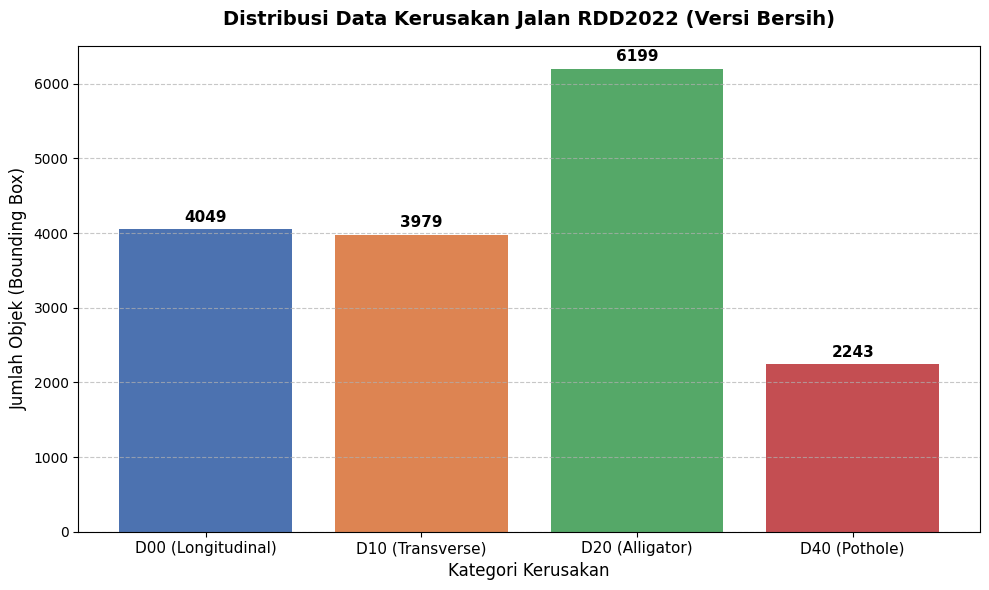

In [ ]:
# ==============================================================================
# CEK DISTRIBUSI KELAS DATASET (VISUALISASI)
# ==============================================================================
import os
import glob
import matplotlib.pyplot as plt
from collections import Counter

# 1. Tentukan path folder dataset yang sudah bersih
folder_dataset = '/content/rdd_data_clean/'

# 2. Cari semua file .txt di semua subfolder (train & val)
label_files = glob.glob(os.path.join(folder_dataset, '**/*.txt'), recursive=True)
print(f"Membaca {len(label_files)} file label untuk menghitung distribusi...")

# Siapkan wadah penghitung
class_counts = Counter()

# 3. Looping untuk membaca isi tiap file
for file_path in label_files:
    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if line.strip(): # Pastikan baris tidak kosong
                # Ambil karakter pertama sebelum spasi (yaitu ID Kelas)
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

# 4. Dictionary Nama Kelas RDD2022 (Sesuaikan jika Anda punya nama beda)
# Biasanya standar RDD2022: 0=D00, 1=D10, 2=D20, 3=D40
nama_kelas = {
    0: 'D00 (Longitudinal)',
    1: 'D10 (Transverse)',
    2: 'D20 (Alligator)',
    3: 'D40 (Pothole)'
}

# 5. Persiapkan data untuk grafik
kelas_terdeteksi = sorted(class_counts.keys())
jumlah_objek = [class_counts[k] for k in kelas_terdeteksi]
label_grafik = [nama_kelas.get(k, f'Kelas {k}') for k in kelas_terdeteksi]

print("\n--- Rincian Jumlah Objek ---")
for lbl, jml in zip(label_grafik, jumlah_objek):
    print(f"{lbl} : {jml} bounding boxes")

# ==============================================================================
# 6. MEMBUAT BAR CHART (GRAFIK BATANG)
# ==============================================================================
plt.figure(figsize=(10, 6))
bars = plt.bar(label_grafik, jumlah_objek, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

# Menambahkan angka detail di atas tiap batang
for bar in bars:
    tinggi = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., tinggi + (max(jumlah_objek)*0.01),
             f'{int(tinggi)}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Distribusi Data Kerusakan Jalan RDD2022 (Versi Bersih)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Kerusakan', fontsize=12)
plt.ylabel('Jumlah Objek (Bounding Box)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=11)

# Tampilkan grafik
plt.tight_layout()
plt.show()

### 📊 Perbandingan Distribusi Kelas: Original (5 Kelas) vs Bersih (4 Kelas)

Berikut adalah ringkasan perubahan komposisi dataset RDD2022 (Subset Jepang) sebelum dan sesudah tahap *Data Cleaning*.

**1. Dataset Original (5 Kategori)**
Total dataset awal memiliki **21.201 objek** dengan proporsi:
* **Alligator Crack:** 29,2% *(Paling dominan)*
* **Other Corruption:** 22,3% *(Kelas ambigu/tidak spesifik)*
* **Longitudinal Crack:** 19,1%
* **Transverse Crack:** 18,8%
* **Pothole:** 10,6% *(Paling sedikit)*

> **Analisis Awal:** Kelas 'Other Corruption' memakan porsi yang sangat besar (22,3%). Karena bentuk kerusakannya bermacam-macam dan tidak memiliki pola visual yang tetap, kehadiran kelas ini berpotensi membuat model YOLO kebingungan saat mencari pola (ekstraksi fitur).

---

**2. Dataset Bersih / Final (4 Kategori)**
Setelah kelas 'Other' dihapus, total dataset menjadi **16.470 objek** dengan proporsi baru:
* **Alligator Crack:** 37,6% *(Makin dominan)*
* **Longitudinal Crack:** 24,6%
* **Transverse Crack:** 24,2%
* **Pothole:** 13,6% *(Tetap minoritas)*

---

**💡 Justifikasi Pembersihan Data (Insight Penelitian)**

1. **Fokus Deteksi Meningkat:** Dengan membuang kelas 'Other', model terbebas dari data yang ambigu (*noise*). Model sekarang bisa memusatkan seluruh kemampuan komputasinya hanya untuk mengenali 4 jenis kerusakan utama yang pola visualnya sangat jelas dan terstruktur.
2. **Ketimpangan Natural (Natural Imbalance):** Jarak persentase yang melebar antara *Alligator Crack* (37,6%) dan *Pothole* (13,6%) adalah kondisi yang sangat wajar dan dibiarkan secara sengaja. Proporsi ini adalah representasi akurat dari kondisi riil infrastruktur jalan raya, di mana retak buaya jauh lebih sering terjadi dan menjalar dibandingkan aspal yang berlubang.
3. **Kecerdasan Bawaan YOLOv8:** Meskipun datanya tidak seimbang secara jumlah, arsitektur YOLOv8 sudah dirancang tangguh untuk menangani kondisi *imbalanced class* ini secara internal, sehingga model tetap dapat belajar mendeteksi *Pothole* dengan baik tanpa perlu melakukan modifikasi manipulatif pada jumlah dataset asli.

In [ ]:
print("\n--- Menyalin dan Mengekstrak Dataset ---")
!cp /content/drive/MyDrive/RDD2022_JP_YOLO/RDD2022_JP_YOLO_v2.zip /content/
!unzip -q /content/RDD2022_JP_YOLO_v2.zip -d /content/rdd_data/
print("Dataset berhasil disiapkan di: /content/rdd_data/")


--- Menyalin dan Mengekstrak Dataset ---
Dataset berhasil disiapkan di: /content/rdd_data/


In [ ]:
# ==============================================================================
# CEK RINCIAN JUMLAH TRAIN & VAL (DATASET BERSIH 4 KELAS)
# ==============================================================================
import os
import glob

# Path dataset bersih Anda
folder_dataset = '/content/rdd_data/'

# Cari semua file .txt
all_labels = glob.glob(os.path.join(folder_dataset, '**/*.txt'), recursive=True)

train_files = 0
val_files = 0
train_boxes = 0
val_boxes = 0
empty_files = 0

for file_path in all_labels:
    # Membedakan Train dan Val dari nama foldernpath-nya
    is_train = 'train' in file_path.lower()
    is_val = 'val' in file_path.lower()

    with open(file_path, 'r') as f:
        # Ambil baris yang tidak kosong
        lines = [line for line in f.readlines() if line.strip()]

    # Menghitung file yang sekarang jadi kosong (Background image)
    if len(lines) == 0:
        empty_files += 1

    if is_train:
        train_files += 1
        train_boxes += len(lines)
    elif is_val:
        val_files += 1
        val_boxes += len(lines)

total_files = train_files + val_files
total_boxes = train_boxes + val_boxes

print("=== HASIL PENGECEKAN DATASET BERSIH (4 KELAS) ===")
print(f"Total Keseluruhan Gambar   : {total_files}")
print(f"Total Bounding Box (Objek) : {total_boxes}")
print(f"Gambar Background (Kosong) : {empty_files} gambar (Bagus untuk mencegah False Positive)\n")

print(f"--- Pembagian Train (Latihan) ---")
if total_files > 0:
    print(f"Jumlah Gambar Train : {train_files} ({(train_files/total_files*100):.1f}%)")
print(f"Jumlah Objek Train  : {train_boxes} bounding boxes\n")

print(f"--- Pembagian Validation (Ujian) ---")
if total_files > 0:
    print(f"Jumlah Gambar Val   : {val_files} ({(val_files/total_files*100):.1f}%)")
print(f"Jumlah Objek Val    : {val_boxes} bounding boxes")

=== HASIL PENGECEKAN DATASET BERSIH (4 KELAS) ===
Total Keseluruhan Gambar   : 9311
Total Bounding Box (Objek) : 16470
Gambar Background (Kosong) : 1411 gambar (Bagus untuk mencegah False Positive)

--- Pembagian Train (Latihan) ---
Jumlah Gambar Train : 7448 (80.0%)
Jumlah Objek Train  : 13125 bounding boxes

--- Pembagian Validation (Ujian) ---
Jumlah Gambar Val   : 1863 (20.0%)
Jumlah Objek Val    : 3345 bounding boxes


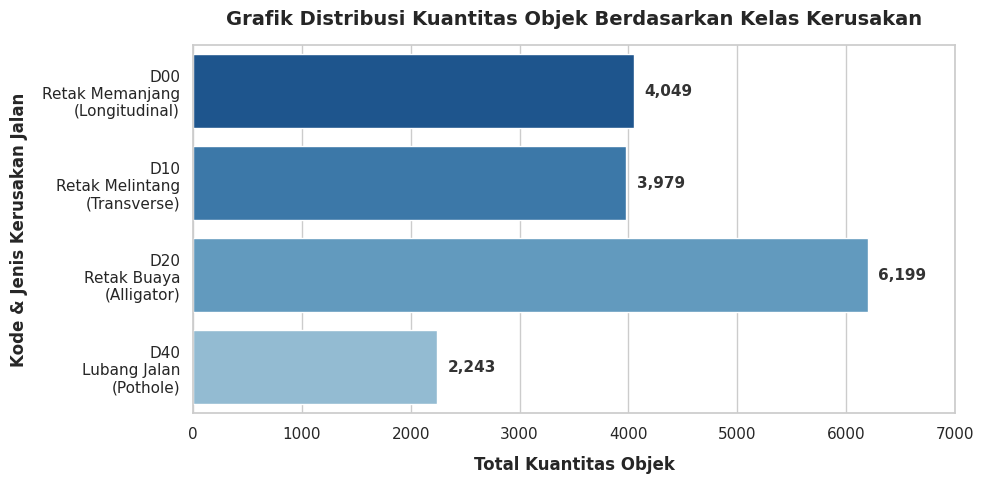

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data dari Tabel 4.2 kamu
kelas = [
    'D00\nRetak Memanjang\n(Longitudinal)',
    'D10\nRetak Melintang\n(Transverse)',
    'D20\nRetak Buaya\n(Alligator)',
    'D40\nLubang Jalan\n(Pothole)'
]
kuantitas = [4049, 3979, 6199, 2243]

# Set tema visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Bikin grafik batang horizontal dengan gradasi warna biru-abu-abu yang formal
colors = sns.color_palette("Blues_r", n_colors=6)[:4]
ax = sns.barplot(x=kuantitas, y=kelas, palette=colors, hue=kelas, legend=False)

# Tambahin angka nominal di ujung setiap batang biar informatif
for i, v in enumerate(kuantitas):
    ax.text(v + 100, i, f"{v:,}", va='center', fontweight='bold', fontsize=11, color='#333333')

# Pengaturan Label dan Judul
plt.xlabel('Total Kuantitas Objek', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Kode & Jenis Kerusakan Jalan', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Grafik Distribusi Kuantitas Objek Berdasarkan Kelas Kerusakan', fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, 7000)

plt.tight_layout()
plt.savefig('distribusi_kelas_rdd2022.png', dpi=300)
plt.show()